# NMF components

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from ipywidgets import Dropdown, interactive, Layout, FloatSlider
from pathlib import Path

plt.rcParams['figure.dpi'] = 150

In [2]:
folder_data = './data/'
loadings = np.concatenate(
    [np.load(folder_data + 'nmf_loadings_1_9.npy', allow_pickle=True), 
     np.load(folder_data + 'nmf_loadings_10_13.npy', allow_pickle=True), 
     np.load(folder_data + 'nmf_loadings_14_16.npy', allow_pickle=True), 
     np.load(folder_data + 'nmf_loadings_17_18.npy', allow_pickle=True), 
     np.load(folder_data + 'nmf_loadings_19_20.npy', allow_pickle=True)])
factors = np.load(folder_data + 'nmf_factors.npy', allow_pickle=True)

In [3]:
ncs = np.arange(1, 21, 1)

loadings_i = np.zeros_like(loadings[-1])
factors_i = np.zeros_like(factors[-1])

i = 4
for ii in np.arange(i+1):
    loadings_i[ii] = loadings[i][ii]
    factors_i[ii] = factors[i][ii]

Dropdown(description='Number of components:', index=4, layout=Layout(width='230px'), options=(np.int64(1), np.…

C:\Users\tinabe\Documents\mini\envs\pm-paper-msa\Lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


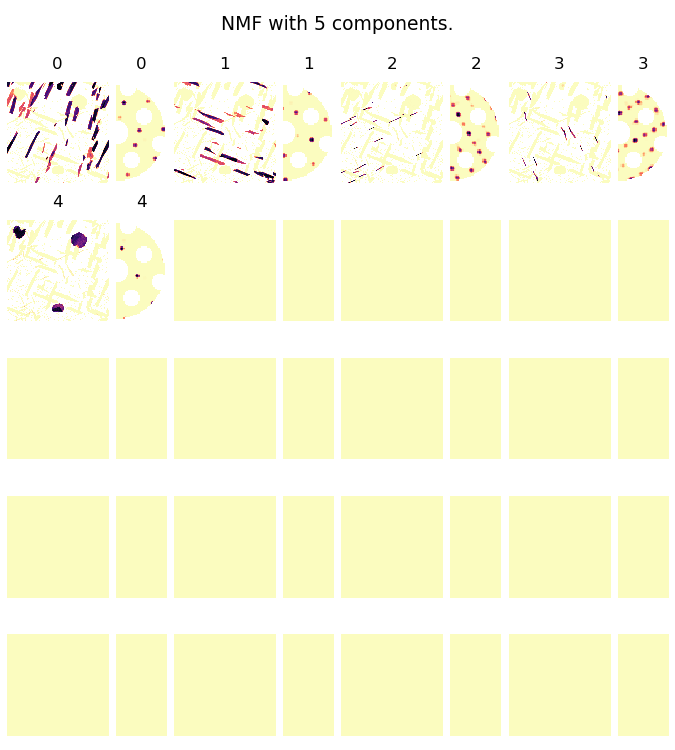

In [4]:
# | label: app:nmf_components_widget
fig = plt.figure(layout='tight', figsize=(4.5, 5))

cmap='magma_r'
axs0, axs1, axs2, axs3, axs4 = fig.subplots(
    5, 8, height_ratios=[1]*5, width_ratios=[1, 0.5]*4, 
    gridspec_kw={'wspace': 0.1, 'left': 0.01, 'right': 0.99, 'bottom': 0.01, 'top': 0.9})

lis = np.arange(0, 10, 2)
fis = np.arange(1, 11, 2)

l_axs = []
f_axs = []
for li, l, fi, f in zip(lis, loadings_i[:4], fis, factors_i[:4]):
    axs0[li].axis('off')
    l_axs.append(axs0[li].imshow(l, cmap=cmap, interpolation='none'))
    axs0[fi].axis('off')
    f_axs.append(axs0[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[4:8], fis, factors_i[4:8]):
    axs1[li].axis('off')
    l_axs.append(axs1[li].imshow(l, cmap=cmap, interpolation='none'))
    axs1[fi].axis('off')
    f_axs.append(axs1[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[8:12], fis, factors_i[8:12]):
    axs2[li].axis('off')
    l_axs.append(axs2[li].imshow(l, cmap=cmap, interpolation='none'))
    axs2[fi].axis('off')
    f_axs.append(axs2[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[12:16], fis, factors_i[12:16]):
    axs3[li].axis('off')
    l_axs.append(axs3[li].imshow(l, cmap=cmap, interpolation='none'))
    axs3[fi].axis('off')
    f_axs.append(axs3[fi].imshow(f, cmap=cmap, interpolation='none'))
for li, l, fi, f in zip(lis, loadings_i[16:20], fis, factors_i[16:20]):
    axs4[li].axis('off')
    l_axs.append(axs4[li].imshow(l, cmap=cmap, interpolation='none'))
    axs4[fi].axis('off')
    f_axs.append(axs4[fi].imshow(f, cmap=cmap, interpolation='none'))
for ii, ax in zip(np.repeat(np.arange(i+1), 2), axs0):
    ax.set_title(str(ii), fontsize=8)
axs1[0].set_title(str(i), fontsize=8)
axs1[1].set_title(str(i), fontsize=8)

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'

fig.suptitle('NMF with ' + str(i+1) + ' components.', fontsize=9)

def update_plot(change):
    i = change['new']-1
    
    loadings_i = np.zeros_like(loadings[-1])
    factors_i = np.zeros_like(factors[-1])
    
    if i>0:
        for ii in np.arange(i+1):
            loadings_i[ii] = loadings[i][ii]
            factors_i[ii] = factors[i][ii]

        titles = ['']*40
        for ii, t in zip(np.arange((i+1)*2), np.repeat(np.arange(i+1), 2)):
            titles[ii] = str(t)

        fig.suptitle('NMF with ' + str(i+1) + ' components.', fontsize=9)
    
    else:
        loadings_i[0] = loadings[0]
        factors_i[0] = factors[0][0]
    
        titles = ['']*40
        titles[0] = str(0)
        titles[1] = str(0)

        fig.suptitle('NMF with ' + str(1) + ' component.', fontsize=9)

    for l_ax, l, f_ax, f in zip(l_axs, loadings_i, f_axs, factors_i):
        l_ax.set_data(l)
        l_ax.set_clim([np.min(l[~np.isnan(l)]), np.max(l[~np.isnan(l)])])
        f_ax.set_data(f)
        f_ax.set_clim([np.min(f[~np.isnan(f)]), np.max(f[~np.isnan(f)])])  
    
    for ax0, t in zip(axs0, titles[:8]):
        ax0.set_title(t, fontsize=8)
    for ax1, t in zip(axs1, titles[8:16]):
        ax1.set_title(t, fontsize=8)    
    for ax2, t in zip(axs2, titles[16:24]):
        ax2.set_title(t, fontsize=8)    
    for ax3, t in zip(axs3, titles[24:32]):
        ax3.set_title(t, fontsize=8)
    for ax4, t in zip(axs4, titles[32:40]):
        ax4.set_title(t, fontsize=8)
        
    fig.canvas.draw_idle()
    return None

nc_widget = Dropdown(options=ncs, index=i, description='Number of components:', 
                     layout=Layout(width='230px'), style={'description_width': '150px'}, disabled=False)
nc_widget.observe(update_plot, names='value')
display(nc_widget)